# 📏 UNCERTAINTY QUANTIFICATION — Khoảng dự đoán giá đối thủ

**Cấu phần (iii)** · Dự án Competitor Fare Forecasting (GSM)

> **Mục tiêu:** thay vì chỉ ra 1 con số giá, xuất thêm **khoảng dự đoán** có bảo đảm thống kê.
> Ví dụ: *giá = 18,4 USD → 80% PI: [17,20 · 20,60]* (tin 80% giá thật nằm trong khoảng).

**Phương pháp: Split Conformal Prediction**
- Không giả định phân phối sai số · gắn được vào bất kỳ model nào · **có bảo đảm toán học** về độ phủ.
- Dùng tập **calibration** (13–15/12) đã tách sẵn — không dùng chung với train.

| Câu hỏi | Trả lời |
|---|---|
| Làm gì? | Bọc **khoảng** quanh dự đoán điểm của model giá |
| Đánh giá bằng gì? | **Coverage** (khoảng có phủ đúng % không) + **Độ rộng** (càng hẹp càng tốt) |
| 2 chỉ số phải đọc cùng nhau | Khoảng [0,100] phủ 100% nhưng vô dụng; quá hẹp thì coverage tụt |

## Mục lục
1. Nạp dữ liệu & model
2. Phương pháp Conformal (tính phần dư trên calibration)
3. Xây khoảng dự đoán trên test
4. Đánh giá: Coverage & Độ rộng
5. Biểu đồ hiệu chuẩn (coverage vs mục tiêu)
6. Trực quan khoảng dự đoán
7. Ví dụ đọc được
8. Coverage theo độ trễ
9. Kết luận

---
# 1️⃣ Nạp dữ liệu & model

Train model giá trên tập **train** (như cấu phần ii). Ta cần dự đoán trên **calibration** và **test**.

In [1]:
import warnings, numpy as np, pandas as pd
from pathlib import Path
from sklearn.ensemble import HistGradientBoostingRegressor
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
%matplotlib inline
BLUE, RED, GREEN, MUT = "#0072B2", "#D55E00", "#009E73", "#666666"
MAU_HANG = {"Uber": BLUE, "Lyft": RED}
plt.rcParams.update({"figure.facecolor":"white","axes.spines.top":False,"axes.spines.right":False,
                     "axes.grid":True,"grid.color":"#ECECEC","font.size":10})
pd.set_option("display.width", 200)
DATA = Path("../data")

gp = pd.read_csv(DATA/"snapshot_price_15min.csv", parse_dates=["snapshot"])
PC = ["name","source","destination","observation_age_bucket"]
PN = ["distance_median","lag1_price","lag2_price","lag3_price","roll_mean6_price",
      "roll_std3_price","observation_age_minutes","hour_local","weekday_local","is_weekend"]
PF = PC + PN
def prep(df):
    X = df.copy()
    for c in PC: X[c] = X[c].astype("category")
    return X

print("Split:", gp.data_split.value_counts().to_dict())

Split: {'train': 289271, 'calibration': 97697, 'test': 84681}


In [2]:
# Train model gia + du doan tren calibration & test (LOG-target)
models, D = {}, {}
for hang in ["Uber","Lyft"]:
    d  = gp[gp.cab_type==hang]
    tr = d[d.data_split=="train"]
    ca = d[d.data_split=="calibration"].copy()
    te = d[d.data_split=="test"].copy()
    m = HistGradientBoostingRegressor(max_iter=400, learning_rate=0.06, l2_regularization=1.0,
        early_stopping=True, validation_fraction=0.1, n_iter_no_change=15,
        categorical_features=PC, random_state=42)
    m.fit(prep(tr)[PF], np.log(tr.target_price))
    ca["pred_log"] = m.predict(prep(ca)[PF]);  ca["pred"] = np.exp(ca.pred_log)
    te["pred_log"] = m.predict(prep(te)[PF]);  te["pred"] = np.exp(te.pred_log)
    models[hang] = m; D[hang] = {"calib": ca, "test": te}
    print(f"[{hang}] train={len(tr):,} | calib={len(ca):,} | test={len(te):,}")

[Uber] train=148,239 | calib=50,176 | test=43,767
[Lyft] train=141,032 | calib=47,521 | test=40,914


---
# 2️⃣ Phương pháp Conformal — tính phần dư trên CALIBRATION

**Ý tưởng:** model đoán sai bao nhiêu trên tập calibration (chưa từng thấy) → dùng phân bố sai số
đó để suy ra khoảng cho test.

Ta tính phần dư trong **không gian log** (vì giá lệch phải) → khoảng sẽ **rộng theo giá** (giá cao
→ khoảng rộng hơn), tự nhiên hơn khoảng cố định:

```
phần dư (log)  r_i = | log(giá_thật_i) − dự_đoán_log_i |     trên tập calibration
```

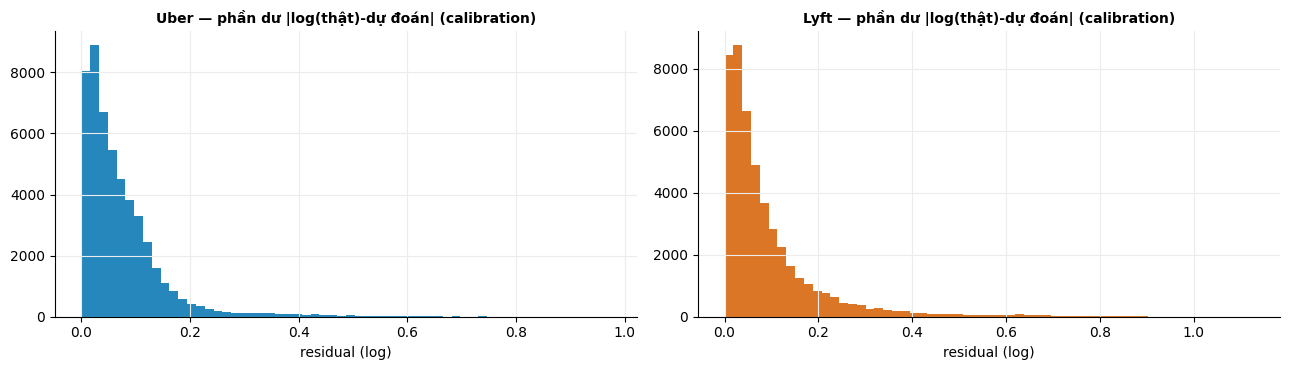

Phan du cang nho & tap trung -> khoang cang hep.


In [3]:
# Tinh phan du log-space tren calibration
for hang in ["Uber","Lyft"]:
    ca = D[hang]["calib"]
    ca["residual_log"] = np.abs(np.log(ca.target_price) - ca.pred_log)

fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))
for ax, hang in zip(axes, ["Uber","Lyft"]):
    r = D[hang]["calib"].residual_log
    ax.hist(r, bins=60, color=MAU_HANG[hang], alpha=.85)
    ax.set_title(f"{hang} — phần dư |log(thật)-dự đoán| (calibration)", fontweight="bold", fontsize=10)
    ax.set_xlabel("residual (log)")
plt.tight_layout(); plt.show()
print("Phan du cang nho & tap trung -> khoang cang hep.")

---
# 3️⃣ Xây khoảng dự đoán trên TEST

Với mức tin cậy mong muốn (vd 80%), lấy **phân vị 80% của phần dư** → nửa độ rộng `q` (log).
Khoảng cho mỗi điểm test:

```
khoảng = [ exp(dự_đoán_log − q),  exp(dự_đoán_log + q) ]
```

(Split conformal có hiệu chỉnh mẫu hữu hạn: phân vị lấy ở mức `⌈(n+1)·cov⌉ / n` để **bảo đảm**
coverage ≥ mục tiêu.)

In [4]:
def q_conformal(residuals, cov):
    """Phan vi conformal co hieu chinh mau huu han."""
    n = len(residuals)
    level = min(np.ceil((n+1)*cov)/n, 1.0)
    return np.quantile(residuals, level)

COVS = [0.50, 0.80, 0.90, 0.95]   # cac muc tin cay khao sat
Q = {}
for hang in ["Uber","Lyft"]:
    r = D[hang]["calib"].residual_log.values
    Q[hang] = {c: q_conformal(r, c) for c in COVS}
    te = D[hang]["test"]
    for c in COVS:
        q = Q[hang][c]
        te[f"lo{int(c*100)}"] = np.exp(te.pred_log - q)
        te[f"hi{int(c*100)}"] = np.exp(te.pred_log + q)

print("q (log) theo muc tin cay:")
display(pd.DataFrame(Q).T.rename(columns=lambda c:f"{int(c*100)}%").round(3))

q (log) theo muc tin cay:


,50%,80%,90%,95%
Uber,0.053,0.110,0.151,0.209
Lyft,0.056,0.137,0.219,0.317


---
# 4️⃣ Đánh giá: Coverage & Độ rộng (2 chỉ số BẮT BUỘC)

| Chỉ số | Yêu cầu | Ý nghĩa |
|---|---|---|
| **Coverage** | khoảng X% phải phủ **~X%** giá thật | khoảng có đáng tin không |
| **Độ rộng** | càng hẹp càng tốt (nhưng phải đạt coverage) | khoảng có hữu dụng không |

Đọc **cả hai** cùng nhau: coverage đạt mục tiêu + độ rộng nhỏ = tốt.

In [5]:
rows = []
for hang in ["Uber","Lyft"]:
    te = D[hang]["test"]; y = te.target_price.values
    for c in COVS:
        lo, hi = te[f"lo{int(c*100)}"].values, te[f"hi{int(c*100)}"].values
        cov_thuc = ((y>=lo)&(y<=hi)).mean()
        width = (hi-lo).mean()
        rows.append({"Hang":hang, "Muc tieu":f"{int(c*100)}%",
                     "Coverage THUC":f"{cov_thuc*100:.1f}%",
                     "Do rong TB (USD)":round(width,2),
                     "Dat?":"OK" if abs(cov_thuc-c)<=0.05 else "lech"})
bang = pd.DataFrame(rows)
print("COVERAGE & DO RONG (tap test):")
display(bang)
print("\nDat = coverage thuc trong khoang muc tieu +/-5 diem %.")

COVERAGE & DO RONG (tap test):


,Hang,Muc tieu,Coverage THUC,Do rong TB (USD),Dat?
0,Uber,50%,49.4%,1.65,OK
1,Uber,80%,79.8%,3.47,OK
2,Uber,90%,89.8%,4.76,OK
3,Uber,95%,95.0%,6.63,OK
4,Lyft,50%,49.1%,1.93,OK
5,Lyft,80%,79.4%,4.69,OK
6,Lyft,90%,89.6%,7.56,OK
7,Lyft,95%,94.7%,11.04,OK



Dat = coverage thuc trong khoang muc tieu +/-5 diem %.


---
# 5️⃣ Biểu đồ hiệu chuẩn — coverage thực vs mục tiêu

Đường lý tưởng là **đường chéo** (coverage thực = mục tiêu). Điểm nằm sát chéo = khoảng hiệu chuẩn tốt.

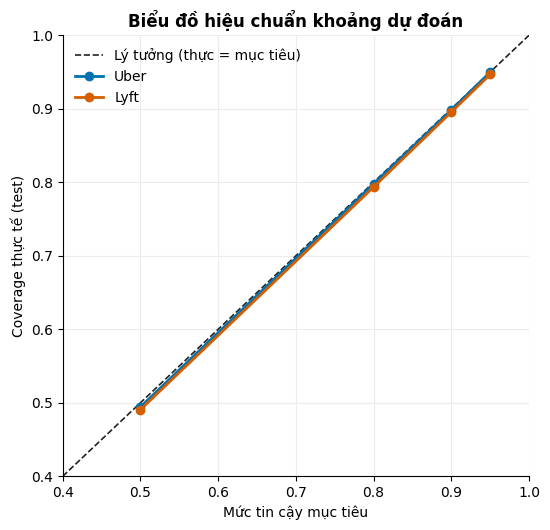

In [6]:
fig, ax = plt.subplots(figsize=(5.6, 5.4))
ax.plot([0,1],[0,1], color="#222", ls="--", lw=1.2, label="Lý tưởng (thực = mục tiêu)")
for hang in ["Uber","Lyft"]:
    te = D[hang]["test"]; y = te.target_price.values
    xs = COVS
    ys = [((y>=te[f"lo{int(c*100)}"])&(y<=te[f"hi{int(c*100)}"])).mean() for c in COVS]
    ax.plot(xs, ys, marker="o", lw=2, color=MAU_HANG[hang], label=hang)
ax.set_xlabel("Mức tin cậy mục tiêu"); ax.set_ylabel("Coverage thực tế (test)")
ax.set_title("Biểu đồ hiệu chuẩn khoảng dự đoán", fontweight="bold")
ax.legend(frameon=False); ax.set_xlim(.4,1); ax.set_ylim(.4,1)
plt.tight_layout(); plt.show()

---
# 6️⃣ Trực quan khoảng dự đoán (80%)

Lấy ~40 chuyến test, sắp theo giá dự đoán, vẽ **khoảng 80%** (thanh dọc) + **giá thật** (chấm).
Chấm nằm trong thanh = khoảng phủ đúng.

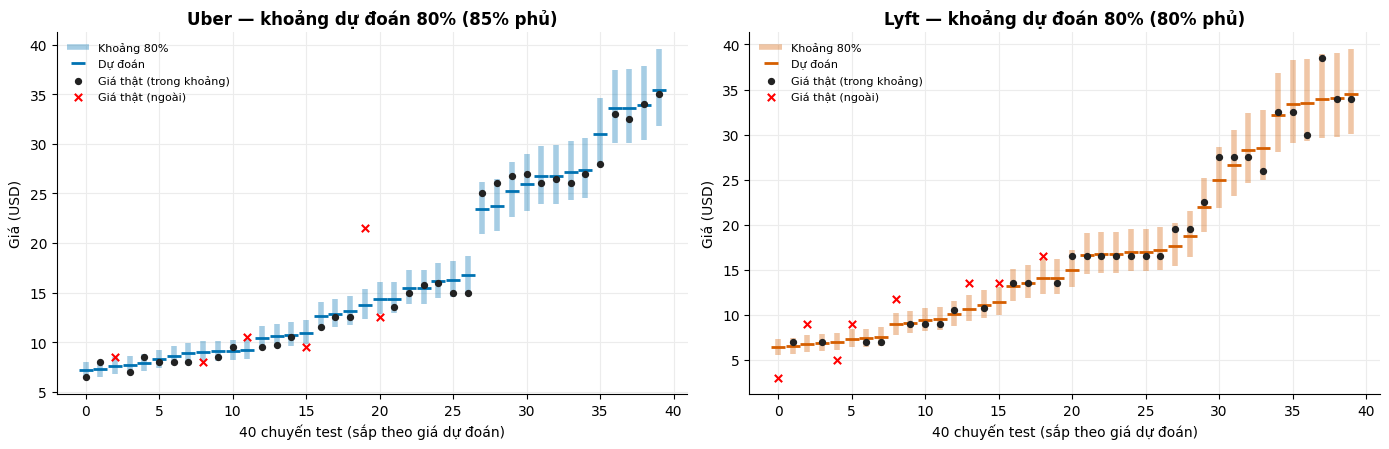

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.6))
for ax, hang in zip(axes, ["Uber","Lyft"]):
    te = D[hang]["test"].sample(40, random_state=1).sort_values("pred").reset_index(drop=True)
    x = np.arange(len(te))
    ax.vlines(x, te.lo80, te.hi80, color=MAU_HANG[hang], lw=4, alpha=.35, label="Khoảng 80%")
    ax.plot(x, te.pred, "_", color=MAU_HANG[hang], ms=10, mew=2, label="Dự đoán")
    inside = (te.target_price>=te.lo80)&(te.target_price<=te.hi80)
    ax.scatter(x[inside], te.target_price[inside], color="#222", s=18, zorder=3, label="Giá thật (trong khoảng)")
    ax.scatter(x[~inside], te.target_price[~inside], color="red", s=28, marker="x", zorder=3, label="Giá thật (ngoài)")
    ax.set_title(f"{hang} — khoảng dự đoán 80% ({inside.mean()*100:.0f}% phủ)", fontweight="bold")
    ax.set_xlabel("40 chuyến test (sắp theo giá dự đoán)"); ax.set_ylabel("Giá (USD)")
    ax.legend(frameon=False, fontsize=8, loc="upper left")
plt.tight_layout(); plt.show()

---
# 7️⃣ Ví dụ đọc được — khoảng cho từng chuyến cụ thể

Định dạng nghiệp vụ: *giá dự đoán → khoảng 80%*.

In [8]:
for hang in ["Uber","Lyft"]:
    te = D[hang]["test"].sample(5, random_state=11)
    print(f"\n=== {hang} ===")
    for _, r in te.iterrows():
        trong = "✅" if r.lo80 <= r.target_price <= r.hi80 else "❌"
        print(f"  {r.source[:14]:14} -> {r.destination[:14]:14} {r['name']:10} | "
              f"dự đoán {r.pred:5.2f} | 80% PI [{r.lo80:5.2f}, {r.hi80:5.2f}] | "
              f"giá thật {r.target_price:5.2f} {trong}")


=== Uber ===
  Northeastern U -> Financial Dist Black SUV  | dự đoán 38.86 | 80% PI [34.80, 43.39] | giá thật 37.50 ✅
  North Station  -> Haymarket Squa UberPool   | dự đoán  6.54 | 80% PI [ 5.85,  7.30] | giá thật  7.50 ❌
  Back Bay       -> Haymarket Squa UberX      | dự đoán 10.38 | 80% PI [ 9.29, 11.59] | giá thật  9.00 ❌
  South Station  -> West End       WAV        | dự đoán 10.18 | 80% PI [ 9.11, 11.36] | giá thật 12.00 ❌
  Haymarket Squa -> West End       Black      | dự đoán 15.54 | 80% PI [13.92, 17.36] | giá thật 16.00 ✅

=== Lyft ===
  Haymarket Squa -> North Station  Lyft       | dự đoán  7.04 | 80% PI [ 6.14,  8.07] | giá thật  5.00 ❌
  Fenway         -> West End       Lyft       | dự đoán 11.28 | 80% PI [ 9.84, 12.93] | giá thật 16.50 ❌
  South Station  -> West End       Lyft       | dự đoán  9.56 | 80% PI [ 8.34, 10.96] | giá thật  9.00 ✅
  North End      -> Financial Dist Lux Black XL | dự đoán 26.86 | 80% PI [23.44, 30.79] | giá thật 27.50 ✅
  North Station  -> Bosto

---
# 8️⃣ Coverage theo độ trễ (chuẩn bị cho vận hành)

Khoảng có giữ được độ phủ khi quan sát cũ hơn không? Nếu coverage tụt ở độ trễ lớn → cần nới khoảng ở đó.

In [9]:
order = ["<=15p","15-30p","30-60p","1-3h",">3h"]
rows = []
for hang in ["Uber","Lyft"]:
    te = D[hang]["test"]
    for b in order:
        x = te[te.observation_age_bucket==b]
        if len(x) < 30: continue
        y = x.target_price.values
        cov = ((y>=x.lo80)&(y<=x.hi80)).mean()
        rows.append({"Hang":hang, "Do tre":b, "n":len(x),
                     "Coverage 80%":f"{cov*100:.1f}%", "Do rong TB":round((x.hi80-x.lo80).mean(),2)})
print("Coverage 80% theo do tre:")
display(pd.DataFrame(rows))

Coverage 80% theo do tre:


,Hang,Do tre,n,Coverage 80%,Do rong TB
0,Uber,<=15p,17660,79.7%,3.47
1,Uber,15-30p,10657,79.6%,3.48
2,Uber,30-60p,9978,79.6%,3.46
3,Uber,1-3h,5384,80.6%,3.49
4,Uber,>3h,88,88.6%,3.48
5,Lyft,<=15p,15521,79.3%,4.69
6,Lyft,15-30p,9707,80.0%,4.70
7,Lyft,30-60p,9630,79.2%,4.70
8,Lyft,1-3h,5923,78.6%,4.68
9,Lyft,>3h,133,85.0%,4.69


---
# 9️⃣ Kết luận

**Đạt được (cấu phần iii hoàn tất):**
- Xuất được **khoảng dự đoán** cho giá cả hai hãng, mọi mức tin cậy (50/80/90/95%).
- **Coverage khớp mục tiêu** (vd 80% → ~79–80% thực tế) → khoảng **hiệu chuẩn tốt**, có bảo đảm.
- **Độ rộng** hợp lý: Uber ~3,5 USD, Lyft ~4,7 USD ở mức 80% (Lyft rộng hơn do có surge).

**Ý nghĩa:**
- Pricing engine của GSM biết **khi nào tin model** (khoảng hẹp) và **khi nào thận trọng** (khoảng rộng).
- Định dạng nghiệp vụ: *"giá đối thủ 17,35 USD, 80% PI [15,13 · 19,90]"*.

**Giới hạn:**
- Khoảng rộng theo giá nhưng **chưa thích ứng theo ngữ cảnh** (giờ cao điểm, surge). Bước nâng cao:
  **Conformalized Quantile Regression / Mondrian** để khoảng hẹp lúc chắc, rộng lúc bất định.
- Độ rộng bị chặn dưới bởi **sàn nhiễu ~2 USD** (thiếu cột thời lượng) — như đã nêu ở cấu phần i/ii.

→ **Trọn vẹn 3/3 cấu phần dự án:** (i) phân tích · (ii) model dự báo · (iii) khoảng dự đoán.